# Prepare

Run `generate_grid_graph_json.py` on whatever configuration you please

# Sampling
Run Julia code to sample partitions, e.g.
```
./sampling/run.sh --map-file data/graph/grid_graph_5_by_5.json --output-file local/output/grid5x5/atlas.jsonl.gz --cycle-walk-steps 1e5 --pop-dev 0.1
```
On a Windows machine through Powershell, something like the following might work:
```
julia --project="sampling/runCycleWalkEnv" sampling/run_cyclewalk.jl --map-file data/graph/grid_graph_5_by_5.json --output-file local/output/grid5x5/atlas.jsonl.gz --cycle-walk-steps 1e5 --pop-dev 0.1 --rng-seed 42
```

# Analysis

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from data import generate_grid_shape, generate_shape_from_json
from hierachical import HClusters
from sample import SampleProcessor
from utils import (
    plot_district,
    plot_plan,
    plot_words_centroids,
    plot_words_list,
    plot_district_by_uid,
)
from word import PlanWordBuilder, WordStat
from scipy.cluster.hierarchy import dendrogram, linkage
from voronoi_gdf import gdf_from_graph_json
import time

square_side = 48
num_districts = 2

PRECINCT_FN = "data/graph/grid_graph_48_by_40_2.json"
SAMPLE_FN = "local/output/grid48x40-2/atlas.jsonl.gz"
OUT_DIR = "local/output/grid48x40-2/processed"
# gdf = generate_grid_shape(square_side)
gdf = generate_shape_from_json(PRECINCT_FN)

start_time = time.time()
# gdf = gdf_from_graph_json(PRECINCT_FN, buffer_factor=0.01)
end_time = time.time()

print(f'gdf generation time: {end_time - start_time} seconds')

is_huge = True if square_side > 4 else False

C:\Users\edzh0\anaconda3\envs\gmstrat\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


gdf generation time: 0.0 seconds


In [2]:
print(gdf.iloc[0])

id                                              0
precinct                                    (0,0)
population                                      1
geometry      POLYGON ((0 0, 1 0, 1 1, 0 1, 0 0))
Name: 0, dtype: object


In [3]:
sp = SampleProcessor(PRECINCT_FN, OUT_DIR)
# run this once to process samples and dump artifacts for future use
sp.clean()
sp.process_samples([SAMPLE_FN], max_length=1000, min_step=100)
sp.load_processed()

Reading local\output\grid48x40-2\atlas.jsonl.gz


plans: 100%|██████████| 1000/1000 [00:00<00:00, 17307.52it/s]


We give each district a unique `district_uid'. Districts are stored via the precincts that they contain (i.e. as an array of ints).

In [4]:
sp.df_districts.head()

,district_str,district_uid
0,0.1.2.3.4.48.49.50.51.52.53.96.97.98.99.100.10...,0
1,0.1.2.3.4.48.49.50.51.52.96.97.98.99.100.144.1...,1
2,0.1.2.3.4.48.49.50.51.52.96.97.98.99.100.144.1...,2
3,0.1.2.3.4.48.49.50.51.52.96.97.98.99.100.144.1...,3
4,0.1.2.3.4.48.49.50.51.96.97.98.99.100.144.145....,4


Each plan is stored using `district_uid's and is given a 'plan_id'

In [5]:
sp.df_plans.head()

,step,plan_id,sample_tag,plan,plan_str
0,1000,0,atlas,"[264, 1552]",264.1552
1,2000,1,atlas,"[937, 1052]",937.1052
2,3000,2,atlas,"[1305, 720]",720.1305
3,4000,3,atlas,"[838, 1162]",838.1162
4,5000,4,atlas,"[1416, 619]",619.1416


We visualize the first sampled plan and its first district

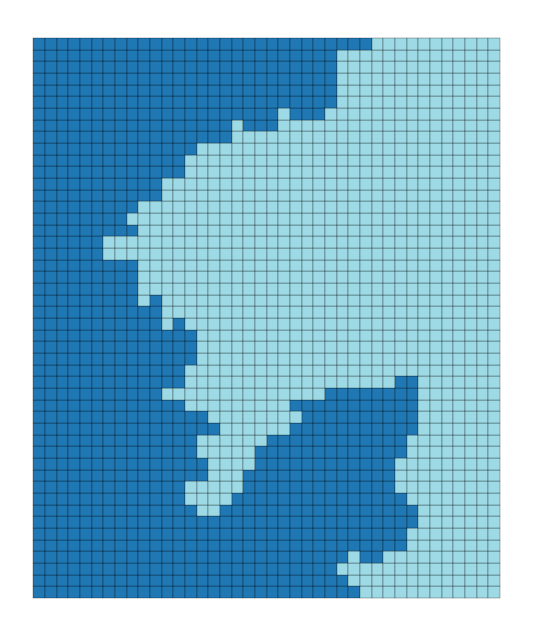

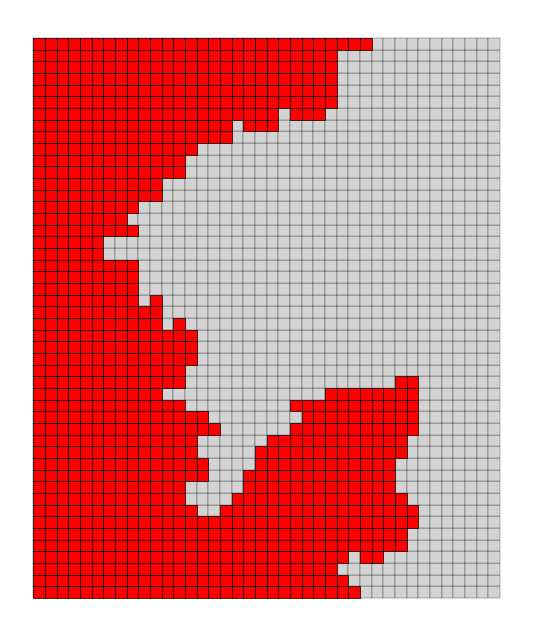

In [6]:
plan = sp.df_plans.iloc[0].plan
labels = sp.decode_plan_vector(plan)
plot_plan(gdf, labels)
plt.show()

district = sp.decode_district(plan[0])
plot_district(gdf, district)
plt.show()

Next, we run hcc and infer clusters at a given number of letters.

In [7]:
sp.load_distance_matrix()
sp.ensure_linkage()

# num_letters = num_districts
num_letters = 4
hc = HClusters(sp)
hc.update_clusters(num_letters)
hc.kcentroids()

  4%|▍         | 2/50 [00:00<00:05,  8.56it/s]

epoch 0: rel_improvement = 0.02916371384455093
epoch 1: rel_improvement = 0.0129863014581591


  4%|▍         | 2/50 [00:00<00:08,  5.78it/s]


We visualize some letters 

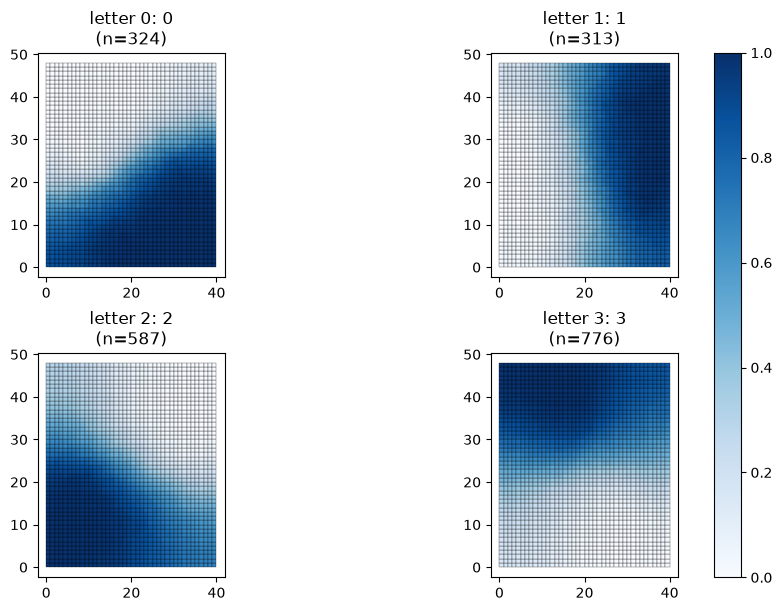

In [8]:
cluster_sizes = np.array([len(hc.c2i[i]) for i in range(num_letters)])

letters = list(range(num_letters))
plot_words_list(gdf, hc.cluster_densities, letters, cluster_sizes=cluster_sizes, cols=2, figsize=(10, 6))
plt.show()

We then use the letters to construct words via beam search with a prescribed `word_degree'

In [9]:
pw = PlanWordBuilder(sp, hc, word_degree=10, verbose=True, centroid_norm="l1").build()
pw.df_words.head()

Enumerating words: 100%|██████████| 1000/1000 [00:00<00:00, 33092.98it/s]


,plan_uid,plan,word,distance,min_distance,plan_str,word_str,word_uid
0,0,"[0, 1841]","[0, 3]",586.0,586.0,0.1841,0.3,3
1,0,"[0, 1841]","[2, 3]",989.0,586.0,0.1841,2.3,8
2,0,"[0, 1841]","[1, 3]",1049.0,586.0,0.1841,1.3,6
3,0,"[0, 1841]","[0, 1]",1457.0,586.0,0.1841,0.1,1
4,0,"[0, 1841]","[0, 2]",1517.0,586.0,0.1841,0.2,2


We compute stationary distribution under some POU (controlled by temperature).

In [10]:
ws = WordStat(pw, temp=0.0, verbose=False)
df_top = ws.stationary_table().head(3).reset_index(drop=True)
df_top

,word_uid,word_str,word,stationary
0,0,0.0,"[0, 0]",0.1
1,1,0.1,"[0, 1]",0.1
2,2,0.2,"[0, 2]",0.1


This is the flux matrix

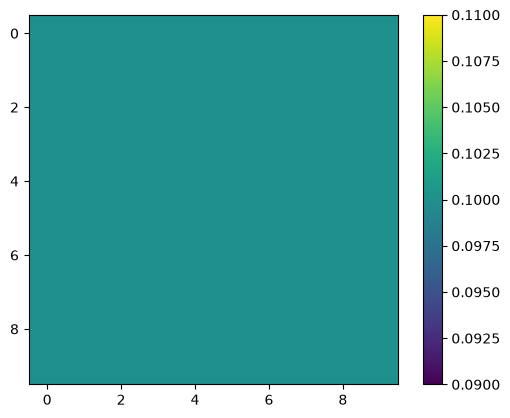

In [11]:
plt.imshow(ws.flux_matrix())
plt.colorbar()

These are some most frequent words under the stationary distribution

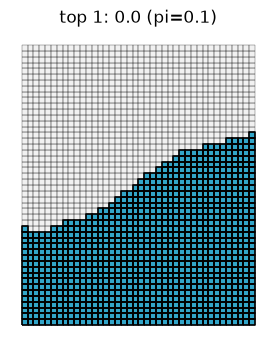

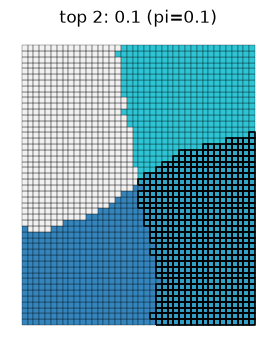

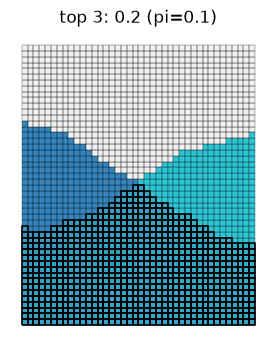

In [12]:
for i, row in df_top.iterrows():
    fig, ax = plot_words_centroids(
        gdf, hc.cluster_densities, row.word, ltr=True, figsize=(4, 4)
    )
    ax.set_title(f"top {i + 1}: {row.word_str} (pi={row.stationary:.3g})")
    plt.show()

Visualize dendrogram from sp linkage

In [13]:
def plot_dendrogram_from_linkage(Z, no_labels=False):
    fig, ax = plt.subplots(figsize=(12, 6))
    dendrogram(Z, ax=ax, no_labels=no_labels)
    ax.set_xlabel("District UID")
    ax.set_ylabel("Merge distance")
    ax.set_title("District clustering dendrogram")
    plt.tight_layout()
    plt.show()
if not is_huge:
    plot_dendrogram_from_linkage(np.load(sp.paths.linkage).astype(np.float64))

In [14]:
# Code by Claude Sonnet 4.6

Z = np.load(sp.paths.linkage).astype(np.float64)
n = int(Z.shape[0] + 1)

from collections import defaultdict

node_to_cluster = {}  # leaf -> cluster id
cluster_members = defaultdict(set)
cluster_first_dist = {}  # cluster id -> distance at which it was first formed
cluster_counter = 0

for i, (a, b, dist, size) in enumerate(Z):
    a, b = int(a), int(b)
    new_node = n + i

    a_leaves = cluster_members[a] if a >= n else {a}
    b_leaves = cluster_members[b] if b >= n else {b}
    cluster_members[new_node] = a_leaves | b_leaves

    a_assigned_leaves = {leaf for leaf in a_leaves if leaf in node_to_cluster}
    b_assigned_leaves = {leaf for leaf in b_leaves if leaf in node_to_cluster}
    a_assigned = len(a_assigned_leaves) > 0
    b_assigned = len(b_assigned_leaves) > 0

    if not a_assigned and not b_assigned:
        cid = cluster_counter
        cluster_counter += 1
        cluster_first_dist[cid] = dist
        for leaf in a_leaves | b_leaves:
            node_to_cluster[leaf] = cid
    elif a_assigned and not b_assigned:
        cid = node_to_cluster[next(iter(a_assigned_leaves))]
        if dist == cluster_first_dist[cid]:
            for leaf in a_leaves | b_leaves:
                node_to_cluster[leaf] = cid
    elif b_assigned and not a_assigned:
        cid = node_to_cluster[next(iter(b_assigned_leaves))]
        if dist == cluster_first_dist[cid]:
            for leaf in a_leaves | b_leaves:
                node_to_cluster[leaf] = cid

# Collect clusters
lowest_level = defaultdict(set)
for leaf, cid in node_to_cluster.items():
    lowest_level[cid].add(leaf)

singletons = [{i} for i in range(n) if i not in node_to_cluster]
all_lowest_clusters = list(lowest_level.values()) + singletons

print(f"{len(all_lowest_clusters)} total lowest-level clusters ({len(singletons)} singletons)")
for c in sorted(all_lowest_clusters, key=len, reverse=True):
    print(sorted(c))

1208 total lowest-level clusters (416 singletons)
[466, 498]
[594, 615]
[1420, 1444]
[1560, 1608]
[718, 740]
[1282, 1307]
[725, 762]
[852, 854]
[1143, 1145]
[1255, 1297]
[655, 686]
[1343, 1377]
[496, 507]
[1545, 1562]
[630, 643]
[18, 981]
[1389, 1402]
[1005, 1984]
[751, 754]
[856, 913]
[1079, 1141]
[1263, 1266]
[598, 702]
[819, 928]
[1061, 1181]
[1323, 1440]
[516, 607]
[1428, 1536]
[649, 705]
[788, 828]
[836, 862]
[1134, 1164]
[1172, 1223]
[1320, 1383]
[419, 420]
[624, 758]
[739, 774]
[838, 853]
[1144, 1162]
[1241, 1283]
[1259, 1411]
[1665, 1666]
[730, 760]
[798, 932]
[1057, 1213]
[1257, 1292]
[486, 517]
[656, 694]
[768, 845]
[791, 857]
[1140, 1220]
[1152, 1249]
[1331, 1376]
[1535, 1578]
[709, 726]
[805, 809]
[793, 867]
[811, 903]
[1090, 1200]
[1202, 1206]
[1129, 1218]
[1296, 1316]
[873, 875]
[1045, 1123]
[563, 572]
[534, 665]
[678, 723]
[732, 759]
[876, 877]
[888, 902]
[1091, 1108]
[1119, 1120]
[1258, 1290]
[1299, 1351]
[1469, 1478]
[1364, 1512]
[385, 412]
[424, 463]
[621, 669]
[735, 

In [15]:
if not is_huge:
    all_lowest_clusters = [sorted(c) for c in all_lowest_clusters]
    largest_LL_cluster_size = max([len(c) for c in all_lowest_clusters])
    n_LL_clusters = len(all_lowest_clusters)
    
    fig, axes = plt.subplots(n_LL_clusters, largest_LL_cluster_size)
    
    for i in range(n_LL_clusters):
        for j in range(len(all_lowest_clusters[i])):
            plot_district_by_uid(gdf, sp.df_districts, all_lowest_clusters[i][j], ax=axes[i][j])
            axes[i][j].text(
                -0.05, 0.5, str(all_lowest_clusters[i][j]),
                transform=axes[i][j].transAxes,
                fontsize=7, va="center", ha="right"
            )
        for j in range(len(all_lowest_clusters[i]), largest_LL_cluster_size):
            plot_district(gdf, np.zeros(len(gdf), dtype=bool), ax=axes[i][j])
    plt.tight_layout()
    plt.show()